# CPE382 Image Processing and Computer Vision Project - **Dice Face Counter**
##4) Integration & Evaluation

**Responsibilities:**

* Combine: OpenCV (detection) + Model (classification)
* Build final pipeline:   ```Input image → detect dice → crop → classify → sum values```
* Visualization:
  * Draw bounding boxes
  * Show detected dots
  * Display total sum
* Evaluate system:
  * Accuracy (>75%)
* Prepare demo

**Output:**
* Final working pipeline
* Demo script
* Evaluation results
* Show output:
  * bounding boxes
  * predicted number
  * total sum



In [1]:
# 0. Setup (RUN FIRST)

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from pathlib import Path
import os
from keras import layers
from sklearn.metrics import f1_score, classification_report
# from google.colab import drive
# drive.mount('/content/drive')
from tensorflow.keras.applications.efficientnet import preprocess_input

### Model Testing By Evaluation F1 Score ###

In [5]:
# 1. Define Paths for testing
path = os.getcwd()
Test_folder = "test"
test_path = os.path.join(path, Test_folder)
print("Test_Path:", test_path)

Test_Path: c:\Users\User\Desktop\CPE\CPE382\Project\Integration\test


In [6]:
#Load model
model = keras.models.load_model("EfficientNetB0.keras")

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,543,799 (17.33 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 329,486 (1.26 MB)

In [93]:
def preprocess_image(img, model_type):

    import cv2
    import numpy as np

    # =====================================================
    # CROP EMPTY SPACE
    # =====================================================

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    coords = cv2.findNonZero(thresh)

    if coords is not None:

        x, y, w, h = cv2.boundingRect(coords)

        padding = 10

        x = max(0, x - padding)
        y = max(0, y - padding)

        w = min(img.shape[1] - x, w + padding * 2)
        h = min(img.shape[0] - y, h + padding * 2)

        img = img[y:y+h, x:x+w]

    # =====================================================
    # RESIZE
    # =====================================================

    img = cv2.resize(img, (224, 224))

    # =====================================================
    # LIGHT DENOISE
    # =====================================================

    img = cv2.GaussianBlur(img, (3, 3), 0)

    # =====================================================
    # FLOAT32
    # =====================================================

    img = img.astype(np.float32)

    # =====================================================
    # MODEL-SPECIFIC PREPROCESS
    # =====================================================

    if model_type == "mobilenet":

        from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
        img = preprocess_input(img)

    elif model_type == "efficientnet":

        from tensorflow.keras.applications.efficientnet import preprocess_input
        img = preprocess_input(img)

    else:

        img = img / 255.0

    return img

In [94]:
def predict_image(image_path, model, model_type, class_names):

    import cv2
    import numpy as np
    import matplotlib.pyplot as plt

    # =====================================================
    # LOAD IMAGE
    # =====================================================

    img = cv2.imread(image_path)

    if img is None:
        raise ValueError("Image not found")

    # =====================================================
    # BGR -> RGB
    # =====================================================

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    original = img.copy()

    # =====================================================
    # PREPROCESS
    # =====================================================

    processed = preprocess_image(img, model_type)

    # =====================================================
    # ADD BATCH DIMENSION
    # =====================================================

    processed = np.expand_dims(processed, axis=0)

    print("Input Shape:", processed.shape)

    # =====================================================
    # PREDICT
    # =====================================================

    pred = model.predict(processed, verbose=0)

    class_id = int(np.argmax(pred, axis=1)[0])

    confidence = float(np.max(pred))

    label = class_names[class_id]

    # =====================================================
    # DISPLAY
    # =====================================================

    plt.imshow(original)
    plt.title(f"Prediction: {label} ({confidence:.4f})")
    plt.axis("off")
    plt.show()

    print("Prediction Vector:")
    print(pred)

    print("Predicted Class :", label)
    print("Confidence      :", confidence)

    return class_id, label, confidence

In [95]:
def evaluate_folder_f1(dataset_folder, model, model_type, class_names, batch_size=32):

    # Create a mapping of class names to integer labels (e.g., {'one_die': 0, 'two_dice': 1})
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}
    
    # Lists to store the final ground truth and predictions
    y_true = []
    y_pred = []
    
    # 1. Gather all file paths and their correct labels
    image_paths = []
    true_labels = []
    
    for class_name in class_names:
        class_folder = os.path.join(dataset_folder, class_name)
        if not os.path.isdir(class_folder):
            print(f"Warning: Folder not found for class '{class_name}'")
            continue
            
        for file_name in os.listdir(class_folder):
            if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(class_folder, file_name))
                true_labels.append(class_to_idx[class_name])
                
    total_images = len(image_paths)
    print(f"Found {total_images} images. Starting evaluation...\n")

    # 2. Process the images in batches to prevent Out Of Memory (OOM) errors
    for i in range(0, total_images, batch_size):
        batch_paths = image_paths[i : i + batch_size]
        batch_labels = true_labels[i : i + batch_size]
        
        batch_images = []
        valid_labels = [] # Tracks labels for images that successfully load/process
        
        # 3. Load and preprocess each image in the current batch
        for path, label in zip(batch_paths, batch_labels):
            img = cv2.imread(path)
            if img is None:
                continue
                
            # Match the BGR -> RGB conversion from your predict_image function
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            try:
                # Apply YOUR custom preprocessing pipeline (crop, resize, denoise, normalize)
                processed = preprocess_image(img, model_type)
                batch_images.append(processed)
                valid_labels.append(label)
            except Exception as e:
                print(f"Error processing {path}: {e}")
                continue
                
        if not batch_images:
            continue
            
        # Convert the list of processed images into a single numpy array batch
        batch_array = np.array(batch_images)
        
        # 4. Get predictions for the batch
        preds = model.predict(batch_array, verbose=0)
        predicted_classes = np.argmax(preds, axis=1)
        
        # Store results
        y_true.extend(valid_labels)
        y_pred.extend(predicted_classes)
        
        print(f"Processed {min(i + batch_size, total_images)} / {total_images} images...")

    # 5. Calculate and print the final metrics
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    print("\n" + "="*50)
    print(f"Overall F1 Score: {f1:.4f}")
    print("="*50)
    
    print("\nDetailed Classification Report:")
    # target_names maps the integer labels back to your text labels for readable output
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    return f1

In [96]:
#Define class
classes = ['1', '2', '3', '4', '5', '6']


evaluate_folder_f1(
    dataset_folder=test_path, 
    model=model, 
    model_type='efficientnet', # Change to 'efficientnet' or 'custom' if needed
    class_names=classes, 
    batch_size=32
)

Found 1161 images. Starting evaluation...

Processed 32 / 1161 images...
Processed 64 / 1161 images...
Processed 96 / 1161 images...
Processed 128 / 1161 images...
Processed 160 / 1161 images...
Processed 192 / 1161 images...
Processed 224 / 1161 images...
Processed 256 / 1161 images...
Processed 288 / 1161 images...
Processed 320 / 1161 images...
Processed 352 / 1161 images...
Processed 384 / 1161 images...
Processed 416 / 1161 images...
Processed 448 / 1161 images...
Processed 480 / 1161 images...
Processed 512 / 1161 images...
Processed 544 / 1161 images...
Processed 576 / 1161 images...
Processed 608 / 1161 images...
Processed 640 / 1161 images...
Processed 672 / 1161 images...
Processed 704 / 1161 images...
Processed 736 / 1161 images...
Processed 768 / 1161 images...
Processed 800 / 1161 images...
Processed 832 / 1161 images...
Processed 864 / 1161 images...
Processed 896 / 1161 images...
Processed 928 / 1161 images...
Processed 960 / 1161 images...
Processed 992 / 1161 images...

np.float64(0.8907119467252891)

### OpenCV Dice Detection ####

### 1 Dot Dice ###


Analyzing Image: dice_004054_0.jpg
Found 1 die/dice on the table.
Individual Dice Values: [1]
🎯 FINAL TOTAL SCORE: 1



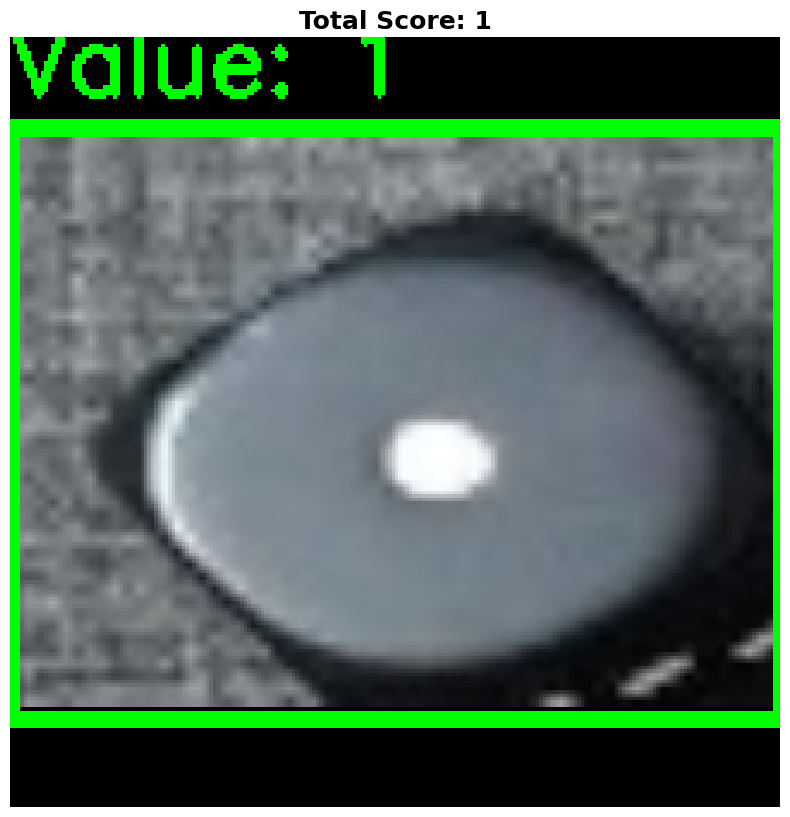

In [3]:
# ==========================================
# 1. SETUP MODEL AND LOCAL PATHS
# ==========================================
# Get the current working directory (where your script is)
BASE_PATH = os.getcwd()

# Point to one specific test image (Update this to a real image name!)
TEST_IMAGE_PATH_1 = os.path.join(BASE_PATH, "test", "1", "dice_004054_0.jpg")

# Load your trained CNN model
MODEL_PATH = os.path.join(BASE_PATH, "EfficientNetB0.keras") 
model = tf.keras.models.load_model(MODEL_PATH)

# Your classes MUST match the numerical values of the dice to do math!
class_names = ['1', '2', '3', '4', '5', '6'] 

# ==========================================
# 2. HELPER FUNCTIONS (Your exact OpenCV logic)
# ==========================================
def load_image(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read: {path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_bgr, img_rgb

def preprocess_image(img_bgr):
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    edges   = cv2.Canny(blurred, threshold1=30, threshold2=100)
    return gray, blurred, edges

def detect_dice(img_bgr, edges, min_area=1500, max_area=None, aspect_ratio_thresh=0.6):
    h, w = img_bgr.shape[:2]
    if max_area is None:
        max_area = (h * w) * 0.5

    kernel  = np.ones((3, 3), np.uint8)
    dilated = cv2.dilate(edges, kernel, iterations=2)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    dice_boxes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area or area > max_area:
            continue
        x, y, bw, bh = cv2.boundingRect(cnt)
        ratio = min(bw, bh) / max(bw, bh)
        if ratio < aspect_ratio_thresh:
            continue
        dice_boxes.append((x, y, bw, bh))

    # Sort boxes left-to-right, top-to-bottom
    dice_boxes.sort(key=lambda b: (b[1] // 50, b[0]))
    return dice_boxes

def crop_dice(img_bgr, dice_boxes, padding=5):
    h, w   = img_bgr.shape[:2]
    crops  = []
    for (x, y, bw, bh) in dice_boxes:
        x1 = max(0, x - padding)
        y1 = max(0, y - padding)
        x2 = min(w, x + bw + padding)
        y2 = min(h, y + bh + padding)
        crops.append(img_bgr[y1:y2, x1:x2])
    return crops

# ==========================================
# 3. MAIN PREDICTION PIPELINE (One Image)
# ==========================================
def calculate_dice_score_1(image_path, cnn_model):
    print(f"\n{'='*50}")
    print(f"Analyzing Image: {os.path.basename(image_path)}")
    
    # --- 1. Load & Detect ---
    img_bgr, img_rgb = load_image(image_path)
    gray, blurred, edges = preprocess_image(img_bgr)
    dice_boxes = detect_dice(img_bgr, edges)
    cropped_dice = crop_dice(img_bgr, dice_boxes)
    
    print(f"Found {len(dice_boxes)} die/dice on the table.")

    if len(dice_boxes) == 0:
        print("⚠️ No dice detected.")
        return 0
        
    total_score = 0
    predictions = []

    # --- 2. Predict Face Value for Each Crop ---
    for i, crop in enumerate(cropped_dice):
        # Format for model exactly like training
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        crop_resized = cv2.resize(crop_rgb, (224, 224))
        crop_float = crop_resized.astype(np.float32)
        crop_input = np.expand_dims(crop_float, axis=0)
        crop_input = preprocess_input(crop_input)

        # Predict
        pred = cnn_model.predict(crop_input, verbose=0)
        class_id = int(np.argmax(pred, axis=1)[0])
        face_value_str = class_names[class_id]
        
        # Convert the string '1', '2', etc. into an actual math integer
        face_value_int = int(face_value_str) 
        
        total_score += face_value_int
        predictions.append(face_value_int)
        
        # Draw the prediction directly on the main image!
        x, y, w, h = dice_boxes[i]
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 3)
        cv2.putText(img_rgb, f"Value: {face_value_int}", (x, y - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    # --- 3. Final Output & Visualization ---
    print(f"Individual Dice Values: {predictions}")
    print(f"🎯 FINAL TOTAL SCORE: {total_score}")
    print(f"{'='*50}\n")

    # Show the final image with boxes and scores drawn on it
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.title(f"Total Score: {total_score}", fontsize=18, fontweight='bold')
    plt.axis("off")
    plt.show()

    return total_score

# ==========================================
# 4. EXECUTE
# ==========================================
final_score = calculate_dice_score_1(TEST_IMAGE_PATH_1, model)

### 2 Dot Dice ###


Analyzing Image: dice_002787_1.jpg
Found 1 die/dice on the table.
Individual Dice Values: [2]
🎯 FINAL TOTAL SCORE: 2



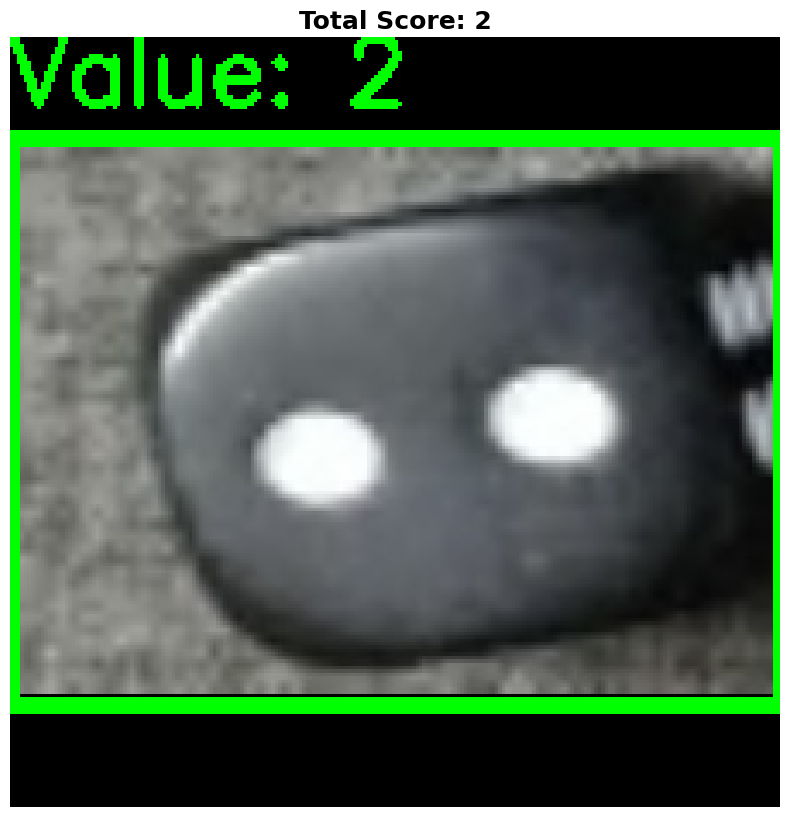

In [10]:
# ==========================================
# 1. SETUP MODEL AND LOCAL PATHS
# ==========================================
# Get the current working directory (where your script is)
BASE_PATH = os.getcwd()

# Point to one specific test image (Update this to a real image name!)
TEST_IMAGE_PATH_2 = os.path.join(BASE_PATH, "test", "2", "dice_002787_1.jpg")

# Load your trained CNN model
MODEL_PATH = os.path.join(BASE_PATH, "EfficientNetB0.keras") 
model = tf.keras.models.load_model(MODEL_PATH)

# Your classes MUST match the numerical values of the dice to do math!
class_names = ['1', '2', '3', '4', '5', '6'] 

# ==========================================
# 2. HELPER FUNCTIONS (Your exact OpenCV logic)
# ==========================================
def load_image(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read: {path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_bgr, img_rgb

def preprocess_image(img_bgr):
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    edges   = cv2.Canny(blurred, threshold1=30, threshold2=100)
    return gray, blurred, edges

def detect_dice(img_bgr, edges, min_area=1500, max_area=None, aspect_ratio_thresh=0.6):
    h, w = img_bgr.shape[:2]
    if max_area is None:
        max_area = (h * w) * 0.5

    kernel  = np.ones((3, 3), np.uint8)
    dilated = cv2.dilate(edges, kernel, iterations=2)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    dice_boxes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area or area > max_area:
            continue
        x, y, bw, bh = cv2.boundingRect(cnt)
        ratio = min(bw, bh) / max(bw, bh)
        if ratio < aspect_ratio_thresh:
            continue
        dice_boxes.append((x, y, bw, bh))

    # Sort boxes left-to-right, top-to-bottom
    dice_boxes.sort(key=lambda b: (b[1] // 50, b[0]))
    return dice_boxes

def crop_dice(img_bgr, dice_boxes, padding=5):
    h, w   = img_bgr.shape[:2]
    crops  = []
    for (x, y, bw, bh) in dice_boxes:
        x1 = max(0, x - padding)
        y1 = max(0, y - padding)
        x2 = min(w, x + bw + padding)
        y2 = min(h, y + bh + padding)
        crops.append(img_bgr[y1:y2, x1:x2])
    return crops

# ==========================================
# 3. MAIN PREDICTION PIPELINE (One Image)
# ==========================================
def calculate_dice_score_1(image_path, cnn_model):
    print(f"\n{'='*50}")
    print(f"Analyzing Image: {os.path.basename(image_path)}")
    
    # --- 1. Load & Detect ---
    img_bgr, img_rgb = load_image(image_path)
    gray, blurred, edges = preprocess_image(img_bgr)
    dice_boxes = detect_dice(img_bgr, edges)
    cropped_dice = crop_dice(img_bgr, dice_boxes)
    
    print(f"Found {len(dice_boxes)} die/dice on the table.")

    if len(dice_boxes) == 0:
        print("⚠️ No dice detected.")
        return 0
        
    total_score = 0
    predictions = []

    # --- 2. Predict Face Value for Each Crop ---
    for i, crop in enumerate(cropped_dice):
        # Format for model exactly like training
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        crop_resized = cv2.resize(crop_rgb, (224, 224))
        crop_float = crop_resized.astype(np.float32)

        # Use the official EfficientNet preprocessor instead of dividing by 255
        crop_input = np.expand_dims(crop_float, axis=0)
        crop_input = preprocess_input(crop_input)

        # Predict
        pred = cnn_model.predict(crop_input, verbose=0)
        class_id = int(np.argmax(pred, axis=1)[0])
        face_value_str = class_names[class_id]
        
        # Convert the string '1', '2', etc. into an actual math integer
        face_value_int = int(face_value_str) 
        
        total_score += face_value_int
        predictions.append(face_value_int)
        
        # Draw the prediction directly on the main image!
        x, y, w, h = dice_boxes[i]
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 3)
        cv2.putText(img_rgb, f"Value: {face_value_int}", (x, y - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    # --- 3. Final Output & Visualization ---
    print(f"Individual Dice Values: {predictions}")
    print(f"🎯 FINAL TOTAL SCORE: {total_score}")
    print(f"{'='*50}\n")

    # Show the final image with boxes and scores drawn on it
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.title(f"Total Score: {total_score}", fontsize=18, fontweight='bold')
    plt.axis("off")
    plt.show()

    return total_score

# ==========================================
# 4. EXECUTE
# ==========================================
final_score = calculate_dice_score_1(TEST_IMAGE_PATH_2, model)

In [11]:
# ==========================================
# 1. SETUP MODEL AND LOCAL PATHS
# ==========================================
# Get the current working directory (where your script is)
BASE_PATH = os.getcwd()

# Point to one specific test image (Update this to a real image name!)
TEST_IMAGE_PATH_3 = os.path.join(BASE_PATH, "test", "3", "dice_003985_0.jpg")

# Load your trained CNN model
MODEL_PATH = os.path.join(BASE_PATH, "EfficientNetB0.keras") 
model = tf.keras.models.load_model(MODEL_PATH)

# Your classes MUST match the numerical values of the dice to do math!
class_names = ['1', '2', '3', '4', '5', '6'] 

# ==========================================
# 2. HELPER FUNCTIONS (Your exact OpenCV logic)
# ==========================================
def load_image(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read: {path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_bgr, img_rgb

def preprocess_image(img_bgr):
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    edges   = cv2.Canny(blurred, threshold1=30, threshold2=100)
    return gray, blurred, edges

def detect_dice(img_bgr, edges, min_area=1500, max_area=None, aspect_ratio_thresh=0.6):
    h, w = img_bgr.shape[:2]
    if max_area is None:
        max_area = (h * w) * 0.5

    kernel  = np.ones((3, 3), np.uint8)
    dilated = cv2.dilate(edges, kernel, iterations=2)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    dice_boxes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area or area > max_area:
            continue
        x, y, bw, bh = cv2.boundingRect(cnt)
        ratio = min(bw, bh) / max(bw, bh)
        if ratio < aspect_ratio_thresh:
            continue
        dice_boxes.append((x, y, bw, bh))

    # Sort boxes left-to-right, top-to-bottom
    dice_boxes.sort(key=lambda b: (b[1] // 50, b[0]))
    return dice_boxes

def crop_dice(img_bgr, dice_boxes, padding=5):
    h, w   = img_bgr.shape[:2]
    crops  = []
    for (x, y, bw, bh) in dice_boxes:
        x1 = max(0, x - padding)
        y1 = max(0, y - padding)
        x2 = min(w, x + bw + padding)
        y2 = min(h, y + bh + padding)
        crops.append(img_bgr[y1:y2, x1:x2])
    return crops

# ==========================================
# 3. MAIN PREDICTION PIPELINE (One Image)
# ==========================================
def calculate_dice_score_3(image_path, cnn_model):
    print(f"\n{'='*50}")
    print(f"Analyzing Image: {os.path.basename(image_path)}")
    
    # --- 1. Load & Detect ---
    img_bgr, img_rgb = load_image(image_path)
    gray, blurred, edges = preprocess_image(img_bgr)
    dice_boxes = detect_dice(img_bgr, edges)
    cropped_dice = crop_dice(img_bgr, dice_boxes)
    
    print(f"Found {len(dice_boxes)} die/dice on the table.")

    if len(dice_boxes) == 0:
        print("⚠️ No dice detected.")
        return 0
        
    total_score = 0
    predictions = []

    # --- 2. Predict Face Value for Each Crop ---
    for i, crop in enumerate(cropped_dice):
        # Format for model exactly like training
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        crop_resized = cv2.resize(crop_rgb, (224, 224))
        crop_normalized = crop_resized.astype(np.float32) / 255.0 
        crop_input = np.expand_dims(crop_normalized, axis=0)

        # Predict
        pred = cnn_model.predict(crop_input, verbose=0)
        class_id = int(np.argmax(pred, axis=1)[0])
        face_value_str = class_names[class_id]
        
        # Convert the string '1', '2', etc. into an actual math integer
        face_value_int = int(face_value_str) 
        
        total_score += face_value_int
        predictions.append(face_value_int)
        
        # Draw the prediction directly on the main image!
        x, y, w, h = dice_boxes[i]
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 3)
        cv2.putText(img_rgb, f"Value: {face_value_int}", (x, y - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    # --- 3. Final Output & Visualization ---
    print(f"Individual Dice Values: {predictions}")
    print(f"🎯 FINAL TOTAL SCORE: {total_score}")
    print(f"{'='*50}\n")

    # Show the final image with boxes and scores drawn on it
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.title(f"Total Score: {total_score}", fontsize=18, fontweight='bold')
    plt.axis("off")
    plt.show()

    return total_score

# ==========================================
# 4. EXECUTE
# ==========================================
final_score = calculate_dice_score_3(TEST_IMAGE_PATH_3, model)


Analyzing Image: dice_003985_0.jpg
Found 0 die/dice on the table.
⚠️ No dice detected.


### 3 Dot Dice ###


Analyzing Image: dice_003717_0.jpg
Found 1 die/dice on the table.
Individual Dice Values: [3]
🎯 FINAL TOTAL SCORE: 3



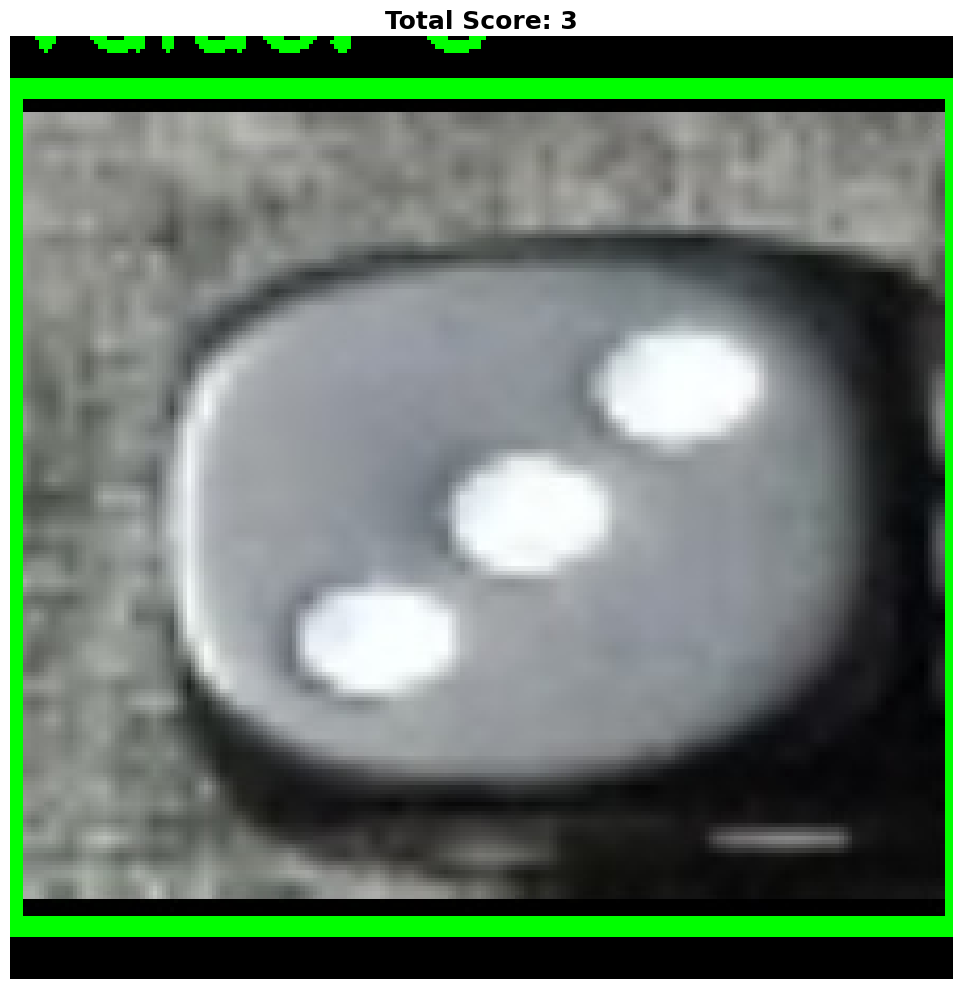

In [22]:

# ==========================================
# 1. SETUP MODEL AND LOCAL PATHS
# ==========================================
BASE_PATH = os.getcwd()

# Point to one specific test image 
TEST_IMAGE_PATH_3 = os.path.join(BASE_PATH, "test", "3", "dice_003717_0.jpg")

# Load your trained CNN model
MODEL_PATH = os.path.join(BASE_PATH, "EfficientNetB0.keras") 
model = tf.keras.models.load_model(MODEL_PATH)

# Your classes MUST match the numerical values of the dice to do math!
class_names = ['1', '2', '3', '4', '5', '6'] 

# ==========================================
# 2. HELPER FUNCTIONS (From Notebook)
# ==========================================
def load_image(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read: {path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_bgr, img_rgb

def preprocess_for_detection(img_bgr):
    """Replaces the old Canny edge detection with your Adaptive Thresholding"""
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (9, 9), 0)
    thresh  = cv2.adaptiveThreshold(
        blurred, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11, 2
    )
    kernel = np.ones((5, 5), np.uint8)
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    return gray, blurred, thresh, closed

def detect_dice(img_bgr, binary_mask, min_area=5000, max_area=None):
    """Updated to match your notebook's detection logic"""
    h, w = img_bgr.shape[:2]
    if max_area is None:
        max_area = h * w * 0.9

    contours, _ = cv2.findContours(
        binary_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    dice_boxes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area or area > max_area:
            continue
        x, y, bw, bh = cv2.boundingRect(cnt)
        aspect_ratio = bw / float(bh)
        if aspect_ratio < 0.6 or aspect_ratio > 1.4:
            continue
        dice_boxes.append((x, y, bw, bh, area))

    # Sort by area descending (largest dice first)
    dice_boxes = sorted(dice_boxes, key=lambda b: b[4], reverse=True)
    return [(x, y, bw, bh) for (x, y, bw, bh, _) in dice_boxes]

def crop_dice(img_bgr, dice_boxes, padding=10):
    h, w = img_bgr.shape[:2]
    crops = []
    for (x, y, bw, bh) in dice_boxes:
        x1 = max(0, x - padding)
        y1 = max(0, y - padding)
        x2 = min(w, x + bw + padding)
        y2 = min(h, y + bh + padding)
        crops.append(img_bgr[y1:y2, x1:x2])
    return crops

def preprocess_for_cnn(img_rgb):
    """Your exact Otsu crop + EfficientNet preprocessing from the notebook"""
    # 1. Crop empty / background space (Otsu)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )
    coords = cv2.findNonZero(thresh)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        if w > 50 and h > 50:           # only crop if result is valid
            pad = 10
            x1 = max(0, x - pad)
            y1 = max(0, y - pad)
            x2 = min(img_rgb.shape[1], x + w + pad)
            y2 = min(img_rgb.shape[0], y + h + pad)
            img_rgb = img_rgb[y1:y2, x1:x2]

    # 2. Resize to EfficientNetB0 input size
    img_rgb = cv2.resize(img_rgb, (224, 224))

    # 3. Light denoise
    img_rgb = cv2.GaussianBlur(img_rgb, (3, 3), 0)

    # 4. EfficientNet normalization (scales to [-1, 1])
    img_float = img_rgb.astype(np.float32)
    img_float = preprocess_input(img_float)

    return img_float

# ==========================================
# 3. MAIN PREDICTION PIPELINE (One Image)
# ==========================================
def calculate_dice_score(image_path, cnn_model):
    print(f"\n{'='*50}")
    print(f"Analyzing Image: {os.path.basename(image_path)}")
    
    # --- 1. Load & Detect ---
    img_bgr, img_rgb = load_image(image_path)
    
    # Using your notebook's detection preprocessing
    gray, blurred, thresh, closed = preprocess_for_detection(img_bgr)
    dice_boxes = detect_dice(img_bgr, closed)
    
    # Handle the fallback logic from your notebook
    if len(dice_boxes) == 0:
        print("⚠️ No dice detected — using full image as fallback")
        cropped_dice = [img_bgr]
        # Create a dummy box covering the whole image for the visualizer
        h, w = img_bgr.shape[:2]
        dice_boxes = [(0, 0, w, h)]
    else:
        cropped_dice = crop_dice(img_bgr, dice_boxes, padding=10)
        
    print(f"Found {len(dice_boxes)} die/dice on the table.")
        
    total_score = 0
    predictions = []

    # --- 2. Predict Face Value for Each Crop ---
    for i, crop in enumerate(cropped_dice):
        # Convert to RGB
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        
        # Apply your exact notebook preprocessing (Otsu crop, resize, blur, preprocess_input)
        crop_processed = preprocess_for_cnn(crop_rgb)
        
        # Add batch dimension
        crop_input = np.expand_dims(crop_processed, axis=0)

        # Predict
        pred = cnn_model.predict(crop_input, verbose=0)
        class_id = int(np.argmax(pred, axis=1)[0])
        face_value_str = class_names[class_id]
        
        # Convert the string '1', '2', etc. into an actual math integer
        face_value_int = int(face_value_str) 
        
        total_score += face_value_int
        predictions.append(face_value_int)
        
        # Draw the prediction directly on the main image
        x, y, w, h = dice_boxes[i]
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 3)
        cv2.putText(img_rgb, f"Value: {face_value_int}", (x, y - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    # --- 3. Final Output & Visualization ---
    print(f"Individual Dice Values: {predictions}")
    print(f"🎯 FINAL TOTAL SCORE: {total_score}")
    print(f"{'='*50}\n")

    # Show the final image with boxes and scores drawn on it
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.title(f"Total Score: {total_score}", fontsize=18, fontweight='bold')
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return total_score

# ==========================================
# 4. EXECUTE
# ==========================================
final_score = calculate_dice_score(TEST_IMAGE_PATH_3, model)

### 4 Dot Dice ###


Analyzing Image: dice_003344_1.jpg
⚠️ No dice detected — using full image as fallback
Found 1 die/dice on the table.
Individual Dice Values: [4]
🎯 FINAL TOTAL SCORE: 4



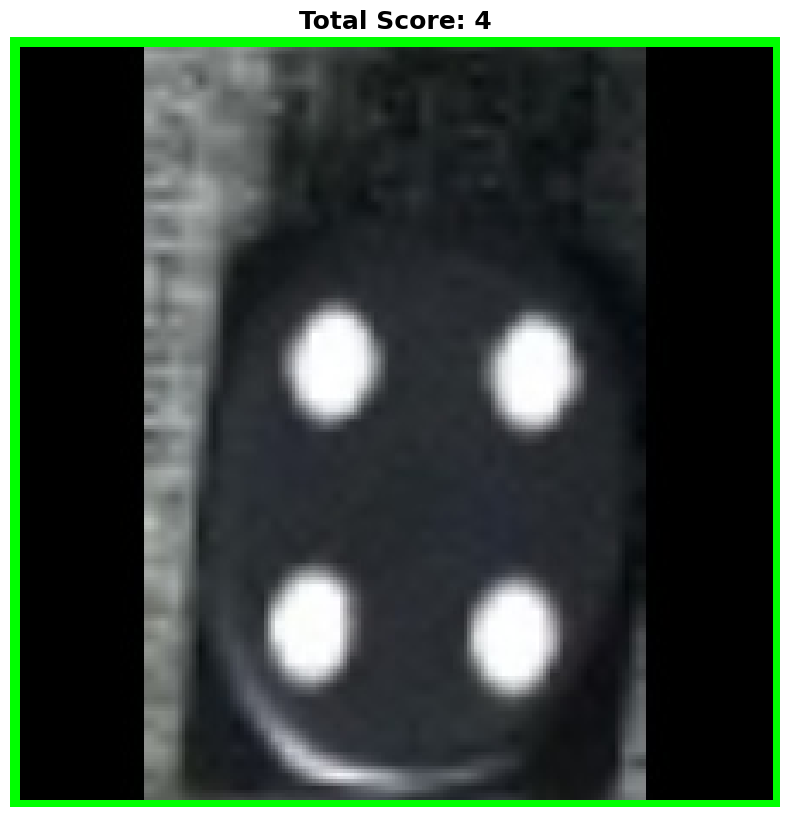

In [23]:
# ==========================================
# 1. SETUP MODEL AND LOCAL PATHS
# ==========================================
# Get the current working directory (where your script is)
BASE_PATH = os.getcwd()

# Point to one specific test image (Update this to a real image name!)
TEST_IMAGE_PATH_4 = os.path.join(BASE_PATH, "test", "4", "dice_003344_1.jpg")

# Load your trained CNN model
MODEL_PATH = os.path.join(BASE_PATH, "EfficientNetB0.keras") 
model = tf.keras.models.load_model(MODEL_PATH)

# Your classes MUST match the numerical values of the dice to do math!
class_names = ['1', '2', '3', '4', '5', '6'] 

# ==========================================
# 2. HELPER FUNCTIONS (Your exact OpenCV logic)
# ==========================================
def load_image(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read: {path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_bgr, img_rgb

def preprocess_image(img_bgr):
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    edges   = cv2.Canny(blurred, threshold1=30, threshold2=100)
    return gray, blurred, edges

def detect_dice(img_bgr, edges, min_area=360, max_area=None, aspect_ratio_thresh=0.6):
    h, w = img_bgr.shape[:2]
    if max_area is None:
        max_area = (h * w) * 0.5

    kernel  = np.ones((3, 3), np.uint8)
    dilated = cv2.dilate(edges, kernel, iterations=2)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    dice_boxes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area or area > max_area:
            continue
        x, y, bw, bh = cv2.boundingRect(cnt)
        ratio = min(bw, bh) / max(bw, bh)
        if ratio < aspect_ratio_thresh:
            continue
        dice_boxes.append((x, y, bw, bh))

    # Sort boxes left-to-right, top-to-bottom
    dice_boxes.sort(key=lambda b: (b[1] // 50, b[0]))
    return dice_boxes

def crop_dice(img_bgr, dice_boxes, padding=5):
    h, w   = img_bgr.shape[:2]
    crops  = []
    for (x, y, bw, bh) in dice_boxes:
        x1 = max(0, x - padding)
        y1 = max(0, y - padding)
        x2 = min(w, x + bw + padding)
        y2 = min(h, y + bh + padding)
        crops.append(img_bgr[y1:y2, x1:x2])
    return crops

# ==========================================
# 3. MAIN PREDICTION PIPELINE (One Image)
# ==========================================
def calculate_dice_score_4(image_path, cnn_model):
    print(f"\n{'='*50}")
    print(f"Analyzing Image: {os.path.basename(image_path)}")
    
    # --- 1. Load & Detect ---
    img_bgr, img_rgb = load_image(image_path)
    
    # Using your notebook's detection preprocessing
    gray, blurred, thresh, closed = preprocess_for_detection(img_bgr)
    dice_boxes = detect_dice(img_bgr, closed)
    
    # Handle the fallback logic from your notebook
    if len(dice_boxes) == 0:
        print("⚠️ No dice detected — using full image as fallback")
        cropped_dice = [img_bgr]
        # Create a dummy box covering the whole image for the visualizer
        h, w = img_bgr.shape[:2]
        dice_boxes = [(0, 0, w, h)]
    else:
        cropped_dice = crop_dice(img_bgr, dice_boxes, padding=10)
        
    print(f"Found {len(dice_boxes)} die/dice on the table.")
        
    total_score = 0
    predictions = []

    # --- 2. Predict Face Value for Each Crop ---
    for i, crop in enumerate(cropped_dice):
        # Convert to RGB
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        
        # Apply your exact notebook preprocessing (Otsu crop, resize, blur, preprocess_input)
        crop_processed = preprocess_for_cnn(crop_rgb)
        
        # Add batch dimension
        crop_input = np.expand_dims(crop_processed, axis=0)

        # Predict
        pred = cnn_model.predict(crop_input, verbose=0)
        class_id = int(np.argmax(pred, axis=1)[0])
        face_value_str = class_names[class_id]
        
        # Convert the string '1', '2', etc. into an actual math integer
        face_value_int = int(face_value_str) 
        
        total_score += face_value_int
        predictions.append(face_value_int)
        
        # Draw the prediction directly on the main image
        x, y, w, h = dice_boxes[i]
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 3)
        cv2.putText(img_rgb, f"Value: {face_value_int}", (x, y - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    # --- 3. Final Output & Visualization ---
    print(f"Individual Dice Values: {predictions}")
    print(f"🎯 FINAL TOTAL SCORE: {total_score}")
    print(f"{'='*50}\n")

    # Show the final image with boxes and scores drawn on it
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.title(f"Total Score: {total_score}", fontsize=18, fontweight='bold')
    plt.axis("off")
    plt.show()

    return total_score

# ==========================================
# 4. EXECUTE
# ==========================================
final_score = calculate_dice_score_4(TEST_IMAGE_PATH_4, model)

### 6 Dot dice ###


Analyzing Image: dice_003521_1.jpg
⚠️ No dice detected — using full image as fallback
Found 1 die/dice on the table.
Individual Dice Values: [6]
🎯 FINAL TOTAL SCORE: 6



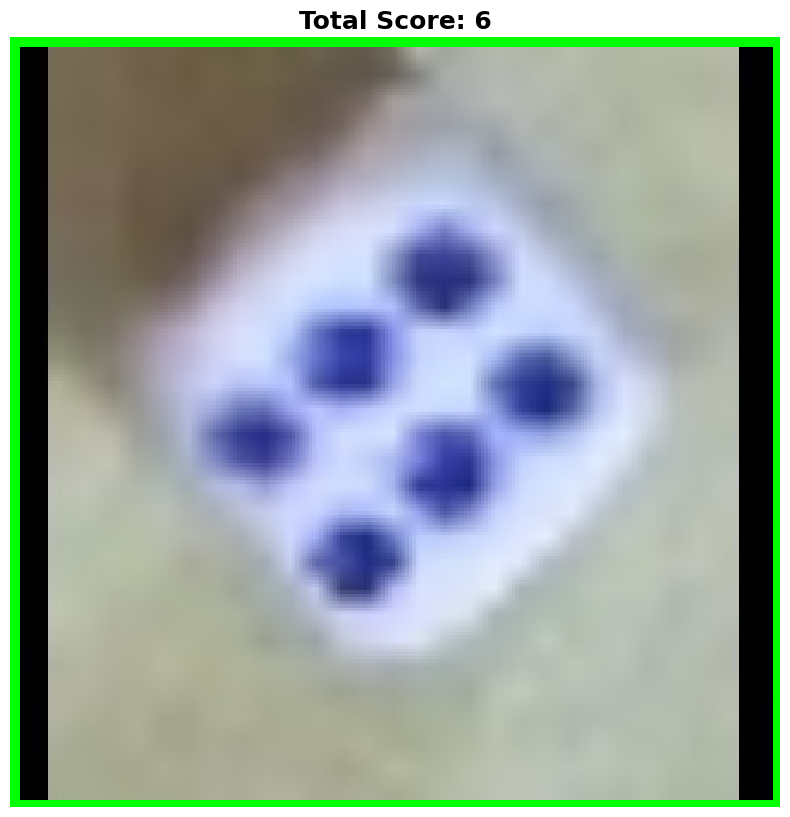

In [25]:
# ==========================================
# 1. SETUP MODEL AND LOCAL PATHS
# ==========================================
# Get the current working directory (where your script is)
BASE_PATH = os.getcwd()

# Point to one specific test image (Update this to a real image name!)
TEST_IMAGE_PATH_6 = os.path.join(BASE_PATH, "test", "6", "dice_003521_1.jpg")

# Load your trained CNN model
MODEL_PATH = os.path.join(BASE_PATH, "EfficientNetB0.keras") 
model = tf.keras.models.load_model(MODEL_PATH)

# Your classes MUST match the numerical values of the dice to do math!
class_names = ['1', '2', '3', '4', '5', '6'] 

# ==========================================
# 2. HELPER FUNCTIONS (Your exact OpenCV logic)
# ==========================================
def load_image(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read: {path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_bgr, img_rgb

def preprocess_image(img_bgr):
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    edges   = cv2.Canny(blurred, threshold1=30, threshold2=100)
    return gray, blurred, edges

def detect_dice(img_bgr, edges, min_area=1500, max_area=None, aspect_ratio_thresh=0.6):
    h, w = img_bgr.shape[:2]
    if max_area is None:
        max_area = (h * w) * 0.5

    kernel  = np.ones((3, 3), np.uint8)
    dilated = cv2.dilate(edges, kernel, iterations=2)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    dice_boxes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area or area > max_area:
            continue
        x, y, bw, bh = cv2.boundingRect(cnt)
        ratio = min(bw, bh) / max(bw, bh)
        if ratio < aspect_ratio_thresh:
            continue
        dice_boxes.append((x, y, bw, bh))

    # Sort boxes left-to-right, top-to-bottom
    dice_boxes.sort(key=lambda b: (b[1] // 50, b[0]))
    return dice_boxes

def crop_dice(img_bgr, dice_boxes, padding=5):
    h, w   = img_bgr.shape[:2]
    crops  = []
    for (x, y, bw, bh) in dice_boxes:
        x1 = max(0, x - padding)
        y1 = max(0, y - padding)
        x2 = min(w, x + bw + padding)
        y2 = min(h, y + bh + padding)
        crops.append(img_bgr[y1:y2, x1:x2])
    return crops

# ==========================================
# 3. MAIN PREDICTION PIPELINE (One Image)
# ==========================================
def calculate_dice_score_5(image_path, cnn_model):
    print(f"\n{'='*50}")
    print(f"Analyzing Image: {os.path.basename(image_path)}")
    
    # --- 1. Load & Detect ---
    img_bgr, img_rgb = load_image(image_path)
    
    # Using your notebook's detection preprocessing
    gray, blurred, thresh, closed = preprocess_for_detection(img_bgr)
    dice_boxes = detect_dice(img_bgr, closed)
    
    # Handle the fallback logic from your notebook
    if len(dice_boxes) == 0:
        print("⚠️ No dice detected — using full image as fallback")
        cropped_dice = [img_bgr]
        # Create a dummy box covering the whole image for the visualizer
        h, w = img_bgr.shape[:2]
        dice_boxes = [(0, 0, w, h)]
    else:
        cropped_dice = crop_dice(img_bgr, dice_boxes, padding=10)
        
    print(f"Found {len(dice_boxes)} die/dice on the table.")
        
    total_score = 0
    predictions = []

    # --- 2. Predict Face Value for Each Crop ---
    for i, crop in enumerate(cropped_dice):
        # Convert to RGB
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        
        # Apply your exact notebook preprocessing (Otsu crop, resize, blur, preprocess_input)
        crop_processed = preprocess_for_cnn(crop_rgb)
        
        # Add batch dimension
        crop_input = np.expand_dims(crop_processed, axis=0)

        # Predict
        pred = cnn_model.predict(crop_input, verbose=0)
        class_id = int(np.argmax(pred, axis=1)[0])
        face_value_str = class_names[class_id]
        
        # Convert the string '1', '2', etc. into an actual math integer
        face_value_int = int(face_value_str) 
        
        total_score += face_value_int
        predictions.append(face_value_int)
        
        # Draw the prediction directly on the main image
        x, y, w, h = dice_boxes[i]
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 3)
        cv2.putText(img_rgb, f"Value: {face_value_int}", (x, y - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    # --- 3. Final Output & Visualization ---
    print(f"Individual Dice Values: {predictions}")
    print(f"🎯 FINAL TOTAL SCORE: {total_score}")
    print(f"{'='*50}\n")

    # Show the final image with boxes and scores drawn on it
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.title(f"Total Score: {total_score}", fontsize=18, fontweight='bold')
    plt.axis("off")
    plt.show()

    return total_score

# ==========================================
# 4. EXECUTE
# ==========================================
final_score = calculate_dice_score_5(TEST_IMAGE_PATH_6, model)

### 5 Dot dice ###


Analyzing Image: dice_004054_1.jpg
Found 1 die/dice on the table.
Individual Dice Values: [5]
🎯 FINAL TOTAL SCORE: 5



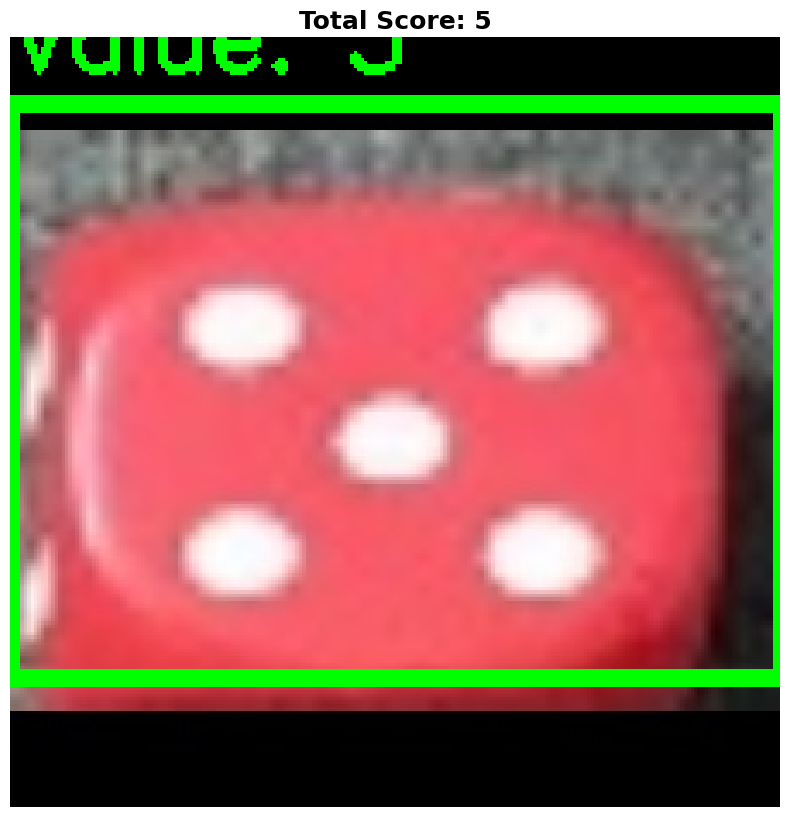

In [28]:
# ==========================================
# 1. SETUP MODEL AND LOCAL PATHS
# ==========================================
# Get the current working directory (where your script is)
BASE_PATH = os.getcwd()

# Point to one specific test image (Update this to a real image name!)
TEST_IMAGE_PATH_5 = os.path.join(BASE_PATH, "test", "5", "dice_004054_1.jpg")

# Load your trained CNN model
MODEL_PATH = os.path.join(BASE_PATH, "EfficientNetB0.keras") 
model = tf.keras.models.load_model(MODEL_PATH)

# Your classes MUST match the numerical values of the dice to do math!
class_names = ['1', '2', '3', '4', '5', '6'] 

# ==========================================
# 2. HELPER FUNCTIONS (Your exact OpenCV logic)
# ==========================================
def load_image(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read: {path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_bgr, img_rgb

def preprocess_image(img_bgr):
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    edges   = cv2.Canny(blurred, threshold1=30, threshold2=100)
    return gray, blurred, edges

def detect_dice(img_bgr, edges, min_area=2000, max_area=None, aspect_ratio_thresh=0.6):
    h, w = img_bgr.shape[:2]
    if max_area is None:
        max_area = (h * w) * 0.5

    kernel  = np.ones((3, 3), np.uint8)
    dilated = cv2.dilate(edges, kernel, iterations=2)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    dice_boxes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area or area > max_area:
            continue
        x, y, bw, bh = cv2.boundingRect(cnt)
        ratio = min(bw, bh) / max(bw, bh)
        if ratio < aspect_ratio_thresh:
            continue
        dice_boxes.append((x, y, bw, bh))

    # Sort boxes left-to-right, top-to-bottom
    dice_boxes.sort(key=lambda b: (b[1] // 50, b[0]))
    return dice_boxes

def crop_dice(img_bgr, dice_boxes, padding=5):
    h, w   = img_bgr.shape[:2]
    crops  = []
    for (x, y, bw, bh) in dice_boxes:
        x1 = max(0, x - padding)
        y1 = max(0, y - padding)
        x2 = min(w, x + bw + padding)
        y2 = min(h, y + bh + padding)
        crops.append(img_bgr[y1:y2, x1:x2])
    return crops



# ==========================================
# 3. MAIN PREDICTION PIPELINE (One Image)
# ==========================================
def calculate_dice_score_6(image_path, cnn_model):
    print(f"\n{'='*50}")
    print(f"Analyzing Image: {os.path.basename(image_path)}")
    
    # --- 1. Load & Detect ---
    img_bgr, img_rgb = load_image(image_path)
    
    # Using your notebook's detection preprocessing
    gray, blurred, thresh, closed = preprocess_for_detection(img_bgr)
    dice_boxes = detect_dice(img_bgr, closed)
    
    # Handle the fallback logic from your notebook
    if len(dice_boxes) == 0:
        print("⚠️ No dice detected — using full image as fallback")
        cropped_dice = [img_bgr]
        # Create a dummy box covering the whole image for the visualizer
        h, w = img_bgr.shape[:2]
        dice_boxes = [(0, 0, w, h)]
    else:
        cropped_dice = crop_dice(img_bgr, dice_boxes, padding=10)
        
    print(f"Found {len(dice_boxes)} die/dice on the table.")
        
    total_score = 0
    predictions = []

    # --- 2. Predict Face Value for Each Crop ---
    for i, crop in enumerate(cropped_dice):
        # Convert to RGB
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        
        # Apply your exact notebook preprocessing (Otsu crop, resize, blur, preprocess_input)
        crop_processed = preprocess_for_cnn(crop_rgb)
        
        # Add batch dimension
        crop_input = np.expand_dims(crop_processed, axis=0)

        # Predict
        pred = cnn_model.predict(crop_input, verbose=0)
        class_id = int(np.argmax(pred, axis=1)[0])
        face_value_str = class_names[class_id]
        
        # Convert the string '1', '2', etc. into an actual math integer
        face_value_int = int(face_value_str) 
        
        total_score += face_value_int
        predictions.append(face_value_int)
        
        # Draw the prediction directly on the main image
        x, y, w, h = dice_boxes[i]
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 3)
        cv2.putText(img_rgb, f"Value: {face_value_int}", (x, y - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    # --- 3. Final Output & Visualization ---
    print(f"Individual Dice Values: {predictions}")
    print(f"🎯 FINAL TOTAL SCORE: {total_score}")
    print(f"{'='*50}\n")

    # Show the final image with boxes and scores drawn on it
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.title(f"Total Score: {total_score}", fontsize=18, fontweight='bold')
    plt.axis("off")
    plt.show()

    return total_score

# ==========================================
# 4. EXECUTE
# ==========================================
final_score = calculate_dice_score_6(TEST_IMAGE_PATH_5, model)